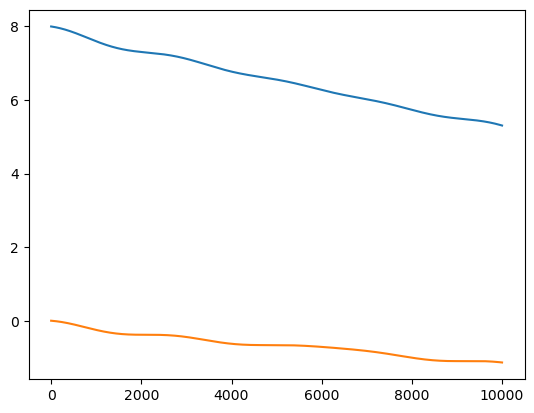

In [2]:
# Setting a linearly declining function for eta
eta_decline_rate = 0.00009  # Customize this rate to control the decline
h[0] = h_init  # Initial height

for p in range(N-1):
    # Calculate width, perimeter, and area
    W[p], P[p], A[p] = aux_area_perimeter_ay2(h[p], a[p])
    # Calculate friction slope
    Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3)) / (A[p]**(10/3))
    # Calculate Froude number squared
    Fr2[p] = (Q**2) * W[p] / (g * (A[p]**3))
    # Calculate height slope considering both linear decline and SF
    dhdx[p] = (S0[p] - Sf[p] - eta_decline_rate) / (1 - Fr2[p])
    # Update the next height value
    h[p+1] = h[p] + dx * dhdx[p]

W[-1], P[-1], A[-1] = aux_area_perimeter_ay2(h[-1], a[-1])
for p in range(N-1):
    W[p], P[p], A[p] = aux_area_perimeter_ay2(h[p], a[p])
    Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3)) / (A[p]**(10/3))
    Fr2[p] = (Q**2) * W[p] / (g * (A[p]**3))

    # Update eta decline directly related to S0 or Sf
    dhdx[p] = (S0[p] - Sf[p] - S0[p] * 0.8) / (1 - Fr2[p])
    h[p+1] = h[p] + dx * dhdx[p]

W[-1], P[-1], A[-1] = aux_area_perimeter_ay2(h[-1], a[-1])
plt.plot(x,np.real(h)+zb); plt.plot(x,zb); plt.show()

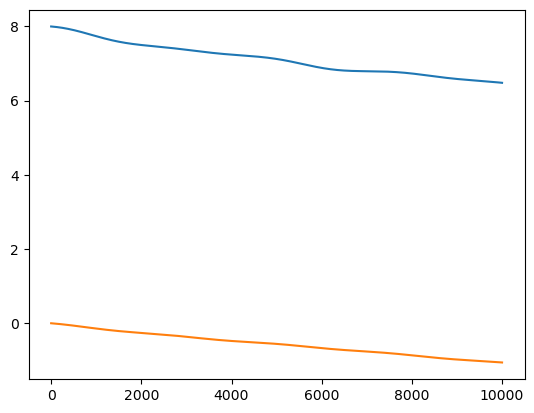

In [1]:
# import packages
import copy
import numpy as np
import math
from scipy import integrate
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import pickle
import time as time
from numpy.random import rand



# Given parabola F=ay^2, what is the width, Perimeter, Area given the height.
def aux_area_perimeter_ay2(h,a):
    
    W = 2*(h/a)**(1/2);
    P = (h/a+4*h**2)**(1/2) + 1/(2*a) * np.arcsinh(2*(a*h)**(1/2)); 
    A = 4/3*h**(3/2)/a**(1/2);

    return W, P, A 

# ----------------------------------------------------------------------- %
# Create mesh: N is number of points, L is length, x is spacial variable
# ----------------------------------------------------------------------- %
### Riverflow direction
N=1000
L=10000
x = (np.linspace(0,L,N))
dx = x[1]-x[0]
 
### Cross sectional direction
Ny=2000; Ly=100;
y = np.array(np.linspace(-Ly,Ly,Ny)); 

### Full river
[X,Y]=np.meshgrid(x,y);

# ----------------------------------------------------------------------- %
# Parameters of river
# ----------------------------------------------------------------------- %
### Flux and Manning coef and gravity (Q,n,g) are constants of the flow
Q = 175; 
n=0.03;
g = 9.81;

### Generate a random S0(x) and a(x), such that bathymetry is z=ay^2
an = 7*rand(5)
an = an.reshape((1,5))  
bn = 5*rand(5)
bn = bn.reshape((1,5))  
coef2 = np.transpose(np.array(range(1,6)))
cs2 = np.tensordot(coef2, x, axes=0) / 2000

# Choice of a gives width of 30 at x=0. 
a = 6/(30/2)**2 * (1+0.1*np.matmul(an,np.sin(cs2)))
a=np.transpose(a)

# S0 has a mean of 0.0001 - realistic value for world rivers
S0 = 0.0001 * (1+0.2*np.matmul(bn,np.sin(cs2)))
S0=np.transpose(S0)



### Integrate to get z_b
zb = integrate.cumtrapz(-S0.reshape(1,N),x,initial=0)
zb = np.transpose(zb)


### Build a river cross-section at every x, like z=ay^2, upon which we can integrate. 
Z=np.zeros([Ny,N])
for p in range(N):
    Z[:,p] = a[p]*Y[:,p]**2

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
#ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,linewidth=0, antialiased=False)

### Manning check, to ensure S0 is the right order of magnitude
h_init = 8;
[W,P,A] = aux_area_perimeter_ay2(h_init,a)
S0_manning = (n**2) * (Q**2) * (P**(4/3)) / (A**(10/3));

#plt.plot(S0); plt.plot(S0_manning);


# ----------------------------------------------------------------------- #
# Time to solve the GVF equations with some initial height at x=0
# ----------------------------------------------------------------------- #
h_init = 8.0
h=np.zeros(N)
h=h.reshape(N,1)
h[0]=h_init
dhdx=np.zeros(N); Sf=np.zeros(N); Fr2=np.zeros(N);
W=np.zeros(N); A=np.zeros(N); P=np.zeros(N);

for p in range(N-1):
    [W[p],P[p],A[p]] = aux_area_perimeter_ay2(h[p],a[p])
    Sf[p] = (n**2) * (Q**2) * (P[p]**(4/3))/((A[p]**(10/3)))
    Fr2[p] = (Q**2)*W[p]/(g*(A[p]**3))
    dhdx[p] = (S0[p]-Sf[p])/(1-Fr2[p]) 
    h[p+1] = h[p] + dx*dhdx[p]
[W[N-1],P[N-1],A[N-1]] = aux_area_perimeter_ay2(h[N-1],a[N-1])


plt.plot(x,np.real(h)+zb); plt.plot(x,zb); plt.show()

 # SAVE THE FILE
 #'_amp=' + str(round(y2[0],4))
filename = 'random_river_data1'  + '.pkl'
with open(filename, 'wb') as file:
    pickle.dump([x,dx,N,L,y,Ny,Ly,X,Y,Q,n,g,a,S0,zb,W,P,A,h,dhdx,Sf,Fr2], file)


#for p=1:N
#    Z(find(Z(:,p)>h(p)),p) = nan;
#end



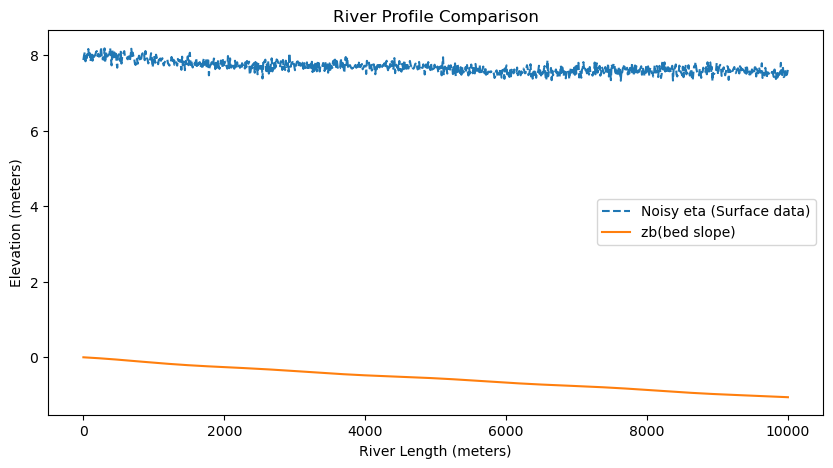

In [3]:
from numpy.random import normal

# Add noise to eta and zb
std_dev_eta = 0.1  # Standard deviation for eta noise
#std_dev_zb = 0.05  # Standard deviation for zb noise

h_noisy = h + normal(0, std_dev_eta, size=h.shape)
#zb_noisy = zb + normal(0, std_dev_zb, size=zb.shape)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(x, h_noisy, label='Noisy eta (Surface data)', linestyle='--')
plt.plot(x, zb, label='zb(bed slope)')
#plt.plot(x, zb_noisy, label='Noisy zb (Bed slope)', alpha=0.5)
plt.title('River Profile Comparison')
plt.xlabel('River Length (meters)')
plt.ylabel('Elevation (meters)')
plt.legend()
plt.show()

# Save the noisy data
filename_noisy = 'random_river_datanoisy1.pkl'
with open(filename_noisy, 'wb') as file:
    pickle.dump([x, dx, N, L, y, Ny, Ly, X, Y, Q, n, g, a, S0, zb, W, P, A, h_noisy, dhdx, Sf, Fr2], file)
